
  多元線性迴歸：作業類型 → 成績

                            OLS Regression Results                            
Dep. Variable:           綜合分析能力測驗答對題數   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     10.74
Date:                Tue, 23 Dec 2025   Prob (F-statistic):           5.33e-25
Time:                        13:16:50   Log-Likelihood:                -5375.6
No. Observations:                1425   AIC:                         1.078e+04
Df Residuals:                    1409   BIC:                         1.087e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const          

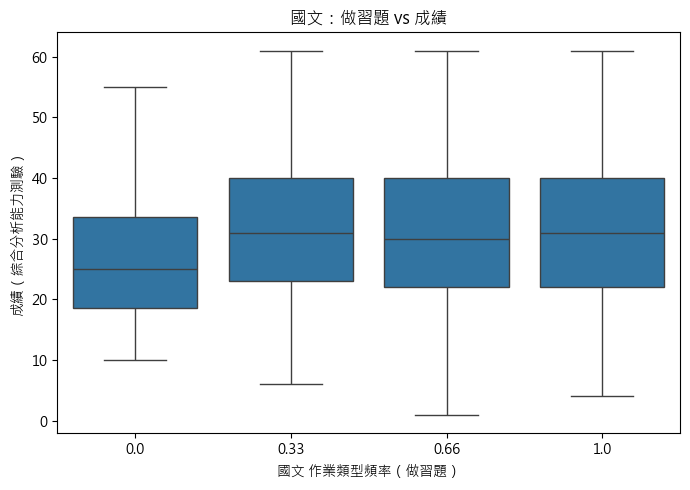

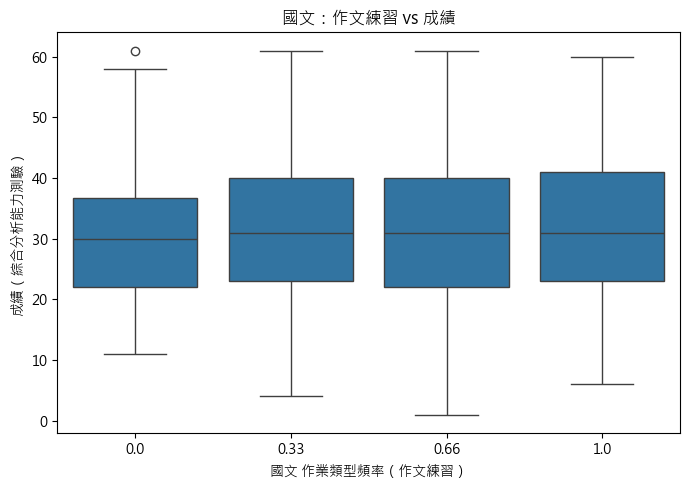

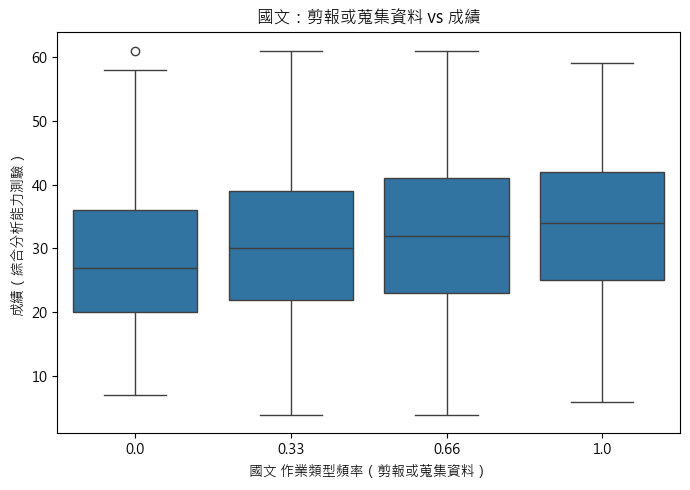

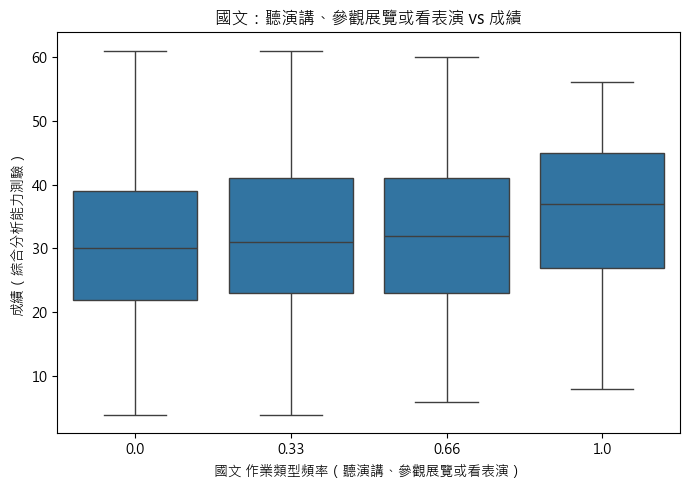

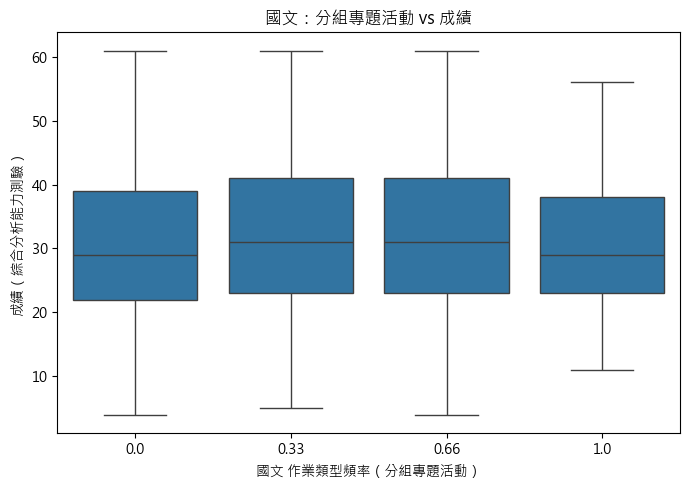

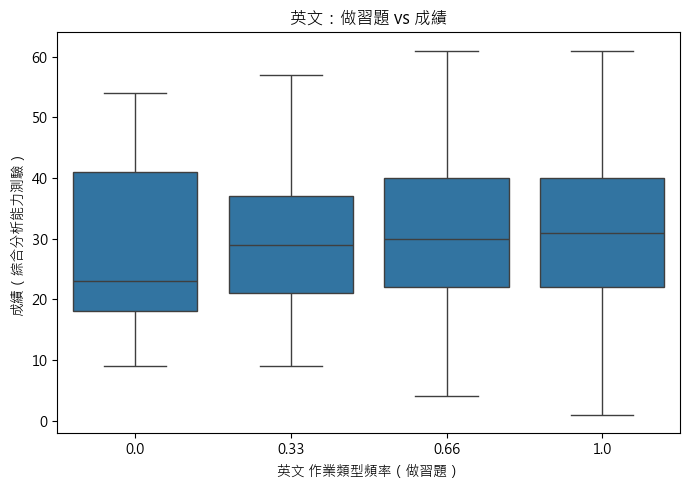

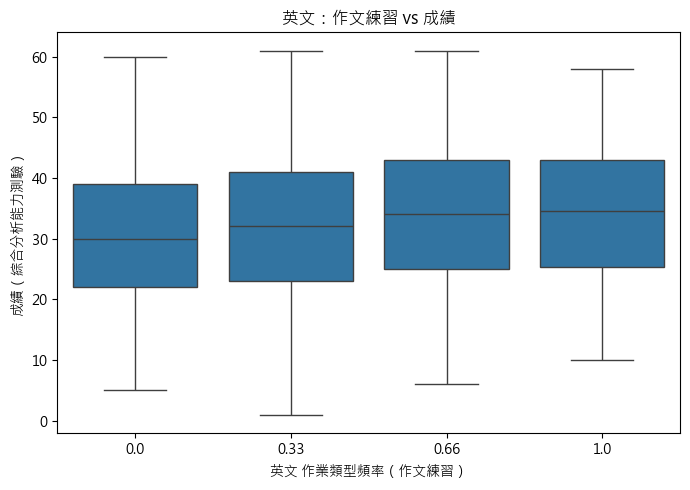

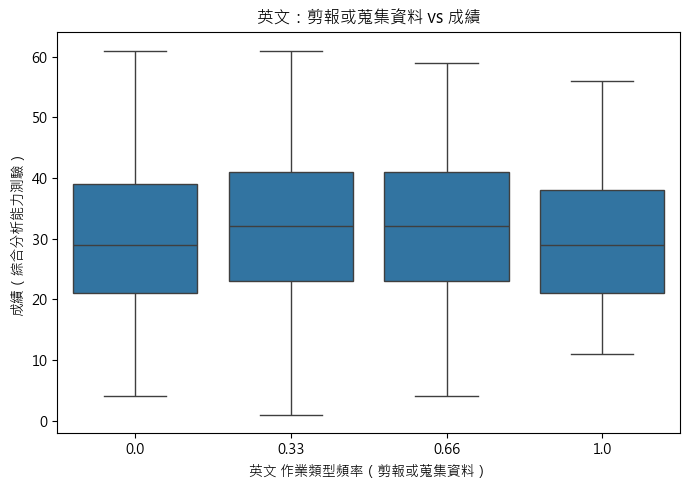

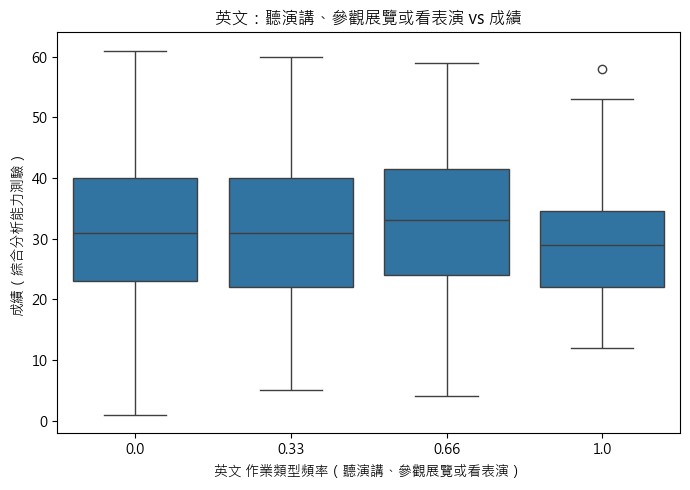

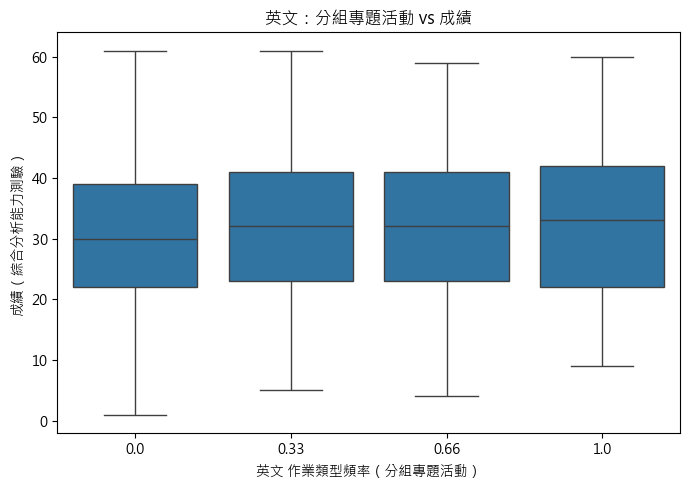

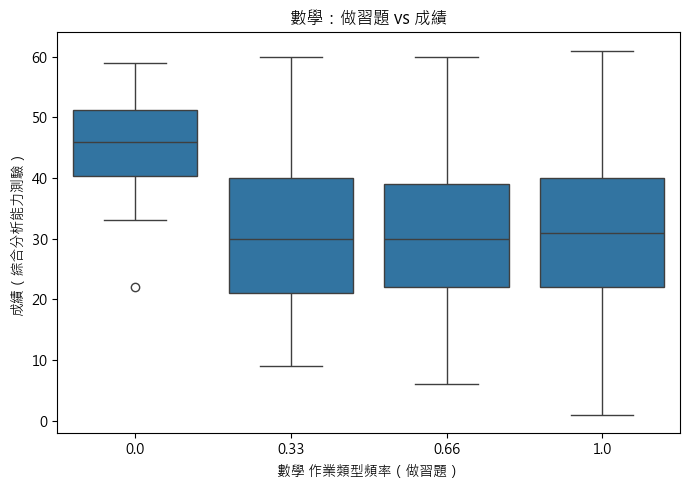

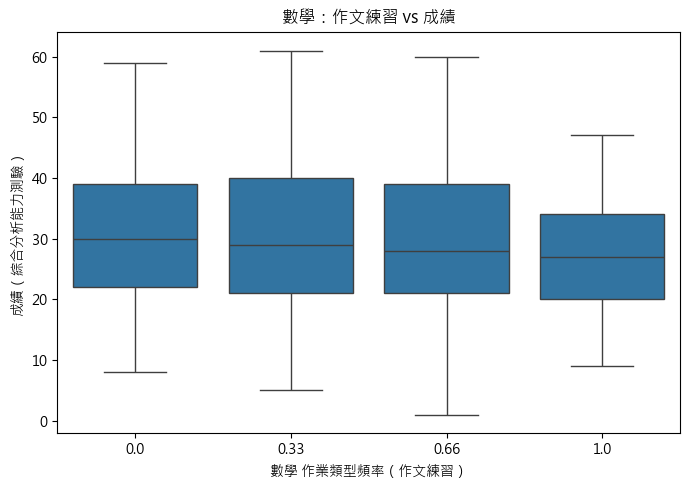

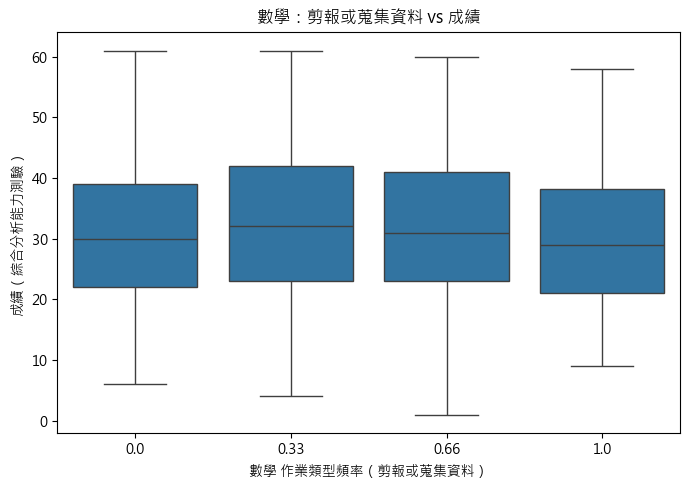

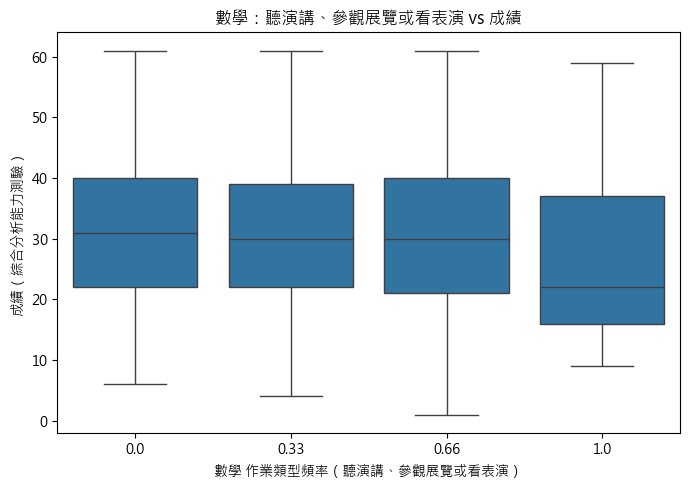

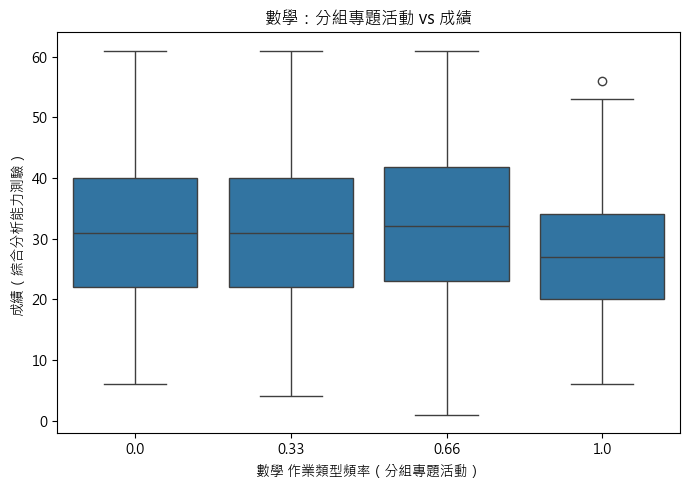

In [ ]:
# ================================================
#  項目 1: 分析作業類型（25~30）對成績的影響
# ================================================

import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='Microsoft JhengHei')

#-------------------------------------------------
# 1. 讀取資料
#-------------------------------------------------
df = pd.read_csv("cleaned_merged_ch.csv", encoding="utf-8-sig")

#-------------------------------------------------
# 2. 選擇作業類型欄位（國文/英文/數學）
#-------------------------------------------------
chi_hw_types  = ["做習題標準化_國文","作文練習標準化_國文",
                 "剪報或蒐集資料標準化_國文","聽演講、參觀展覽或看表演標準化_國文",
                 "分組專題活動標準化_國文"]
eng_hw_types  = ["做習題標準化_英文","作文練習標準化_英文",
                 "剪報或蒐集資料標準化_英文","聽演講、參觀展覽或看表演標準化_英文",
                 "分組專題活動標準化_英文"]
math_hw_types = ["做習題標準化_數學","作文練習標準化_數學",
                 "剪報或蒐集資料標準化_數學","聽演講、參觀展覽或看表演標準化_數學",
                 "分組專題活動標準化_數學"]

all_hw_types = chi_hw_types + eng_hw_types + math_hw_types

#-------------------------------------------------
# 3. 預測目標：統一後的成績
#-------------------------------------------------
target = "綜合分析能力測驗答對題數"   # 綜合分析能力測驗的答對題數

#-------------------------------------------------
# 4. 準備資料：取出需要的欄位
#-------------------------------------------------
analysis_df = df[[target] + all_hw_types].dropna()

#-------------------------------------------------
# 5. 迴歸模型：作業類型 → 成績
#-------------------------------------------------

X = analysis_df[all_hw_types]
X = sm.add_constant(X)  # 加截距
y = analysis_df[target]

model = sm.OLS(y, X).fit()

print("\n===============================")
print("  多元線性迴歸：作業類型 → 成績")
print("===============================\n")
print(model.summary())

#-------------------------------------------------
# 6. 繪製箱型圖：不同作業類型的頻率 vs 成績
#-------------------------------------------------

def plot_boxplot(feature, subject_name):
    plt.figure(figsize=(7, 5))
    sns.boxplot(x=df[feature], y=df[target])
    plt.xlabel(f"{subject_name} 作業類型頻率（{feature[:-6]}）")
    plt.ylabel("成績（綜合分析能力測驗）")
    plt.title(f"{subject_name}：{feature[:-6]} vs 成績")
    plt.tight_layout()
    plt.show()

# 國文
for col in chi_hw_types:
    plot_boxplot(col, "國文")

# 英文
for col in eng_hw_types:
    plot_boxplot(col, "英文")

# 數學
for col in math_hw_types:
    plot_boxplot(col, "數學")
